In [1]:
# STEP 1: Install dependencies
!pip install kaggle pandas matplotlib seaborn wordcloud

# Standard imports
import os, re, math, json, random
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud

print("✅ All libraries installed!")

✅ All libraries installed!


In [1]:
# STEP 2A: Upload your kaggle.json file
from google.colab import files
files.upload()  # Upload kaggle.json when prompted

# STEP 2B: Configure Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle configured!")

# STEP 2C: Download the LinkedIn Job Postings dataset
!kaggle datasets download -d arshkon/linkedin-job-postings --unzip -p ./data
print("✅ Dataset downloaded!")

# STEP 2D: See what files we have
import os
for f in os.listdir('./data'):
    print(f)

Saving Kaggle API Credentials.json to Kaggle API Credentials.json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle configured!
Dataset URL: https://www.kaggle.com/datasets/arshkon/linkedin-job-postings
License(s): CC-BY-SA-4.0
100% 159M/159M [00:01<00:00, 119MB/s]

✅ Dataset downloaded!
postings.csv
mappings
jobs
companies


In [5]:
# STEP 3: Load and explore
import pandas as pd
df = pd.read_csv('./data/postings.csv')

print(f"📦 Shape: {df.shape}")
print(f"\n📋 Columns:\n{df.columns.tolist()}")
print(f"\n🔍 Sample:\n{df.head(3)}")
print(f"\n❓ Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

📦 Shape: (123849, 31)

📋 Columns:
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

🔍 Sample:
     job_id            company_name                              title  \
0    921716   Corcoran Sawyer Smith              Marketing Coordinator   
1   1829192                     NaN  Mental Health Therapist/Counselor   
2  10998357  The National Exemplar         Assitant Restaurant Manager   

                                         description  max_salary pay_period  \
0  Job descriptionA leading real estate firm in N...        20.0     HOURLY   
1  At Aspen Therapy a

In [6]:
# STEP 3B: Keep only useful columns & drop nulls
cols = ['title', 'description', 'location', 'company_name',
        'formatted_experience_level', 'formatted_work_type']

# Keep only columns that exist in this dataset
cols = [c for c in cols if c in df.columns]
df = df[cols].dropna(subset=['title', 'description'])
df = df.reset_index(drop=True)

print(f"✅ Clean dataset: {df.shape[0]} job postings")
print(f"\n🏢 Top companies:\n{df['company_name'].value_counts().head(10)}")
print(f"\n💼 Job title sample:\n{df['title'].value_counts().head(10)}")

✅ Clean dataset: 123842 job postings

🏢 Top companies:
company_name
Liberty Healthcare and Rehabilitation Services    1108
The Job Network                                   1003
J. Galt                                            604
TEKsystems                                         529
Lowe's Companies, Inc.                             527
Ingersoll Rand                                     517
Capital One                                        496
Cogent Communications                              476
Insight Global                                     418
Dice                                               415
Name: count, dtype: int64

💼 Job title sample:
title
Sales Manager                      673
Customer Service Representative    373
Project Manager                    354
Administrative Assistant           254
Senior Accountant                  238
Executive Assistant                228
Salesperson                        211
Registered Nurse                   210
Receptionist     

In [7]:
# STEP 4A: Define a tech skill keyword dictionary (from scratch, like the book!)
SKILLS = {
    "Programming":   ["python", "r", "sql", "java", "scala", "c++", "julia", "bash"],
    "ML/AI":         ["machine learning", "deep learning", "nlp", "computer vision",
                      "neural network", "llm", "transformers", "reinforcement learning"],
    "Libraries":     ["pandas", "numpy", "scikit-learn", "tensorflow", "pytorch",
                      "keras", "matplotlib", "seaborn", "huggingface"],
    "Cloud":         ["aws", "gcp", "azure", "databricks", "snowflake", "bigquery"],
    "Data Eng":      ["spark", "kafka", "airflow", "dbt", "etl", "pipeline",
                      "data warehouse", "hadoop"],
    "Visualization": ["tableau", "power bi", "looker", "qlik", "plotly", "dashboards"],
    "Soft Skills":   ["communication", "teamwork", "leadership", "problem solving",
                      "collaboration", "agile", "stakeholder"],
}

# Flatten to a single lookup list
ALL_SKILLS = {skill: category
              for category, skills in SKILLS.items()
              for skill in skills}

print(f"✅ Tracking {len(ALL_SKILLS)} skills across {len(SKILLS)} categories")

✅ Tracking 52 skills across 7 categories


In [13]:
# STEP 4B FAST: Process all text at once instead of regex per skill per row

def extract_skills_fast(text):
    """Faster skill extraction using simple string matching."""
    if not isinstance(text, str):
        return []
    text = text.lower()  # just lowercase, no heavy cleaning needed
    found = []
    for skill in ALL_SKILLS:
        if skill in text:  # simple 'in' check — 10x faster than regex
            found.append(skill)
    return found

# Apply on a SAMPLE first to test (remove .head(2000) later if you want all data)
print("⏳ Extracting skills... (using fast method on 2000 rows sample)")

df = df.head(2000).copy()  # ← work with 2000 rows, fast & sufficient
df['skills_found'] = df['description'].apply(extract_skills_fast)
df['skill_count']  = df['skills_found'].apply(len)

print(f"✅ Done!")
print(f"📊 Avg skills per posting : {df['skill_count'].mean():.1f}")
print(f"📊 Max skills in a posting: {df['skill_count'].max()}")
print(f"\n🔍 Sample:")
print(f"  Title : {df['title'].iloc[0]}")
print(f"  Skills: {df['skills_found'].iloc[0]}")

⏳ Extracting skills... (using fast method on 2000 rows sample)
✅ Done!
📊 Avg skills per posting : 2.7
📊 Max skills in a posting: 17

🔍 Sample:
  Title : Marketing Coordinator
  Skills: ['r']


In [14]:
# Fix: remove the false 'r' match by excluding single-char skills from short words
df['skills_found'] = df['skills_found'].apply(
    lambda skills: [s for s in skills if len(s) > 1]
)
df['skill_count'] = df['skills_found'].apply(len)

print("✅ Fixed! Sample after cleanup:")
print(f"  Title : {df['title'].iloc[0]}")
print(f"  Skills: {df['skills_found'].iloc[0]}")
print(f"📊 Avg skills per posting: {df['skill_count'].mean():.1f}")

✅ Fixed! Sample after cleanup:
  Title : Marketing Coordinator
  Skills: []
📊 Avg skills per posting: 1.7


WORD FREQUENCY AND TOP SKILL ANALYSIS

In [16]:
# STEP 5A: Most in-demand skills overall (Ch. 1 — Counter from scratch)
import matplotlib.pyplot as plt
from collections import Counter
all_skills_flat = [skill for skills in df['skills_found'] for skill in skills]
skill_counter = Counter(all_skills_flat)

print("🏆 Top 20 Most In-Demand Skills:")
for skill, count in skill_counter.most_common(20):
    bar = '█' * (count // max(1, skill_counter.most_common(1)[0][1] // 30))
    category = ALL_SKILLS[skill]
    print(f"  {skill:<22} [{category:<15}] {bar} ({count})")

🏆 Top 20 Most In-Demand Skills:
  communication          [Soft Skills    ] ██████████████████████████████ (1120)
  leadership             [Soft Skills    ] ███████████ (443)
  aws                    [Cloud          ] ███████ (281)
  stakeholder            [Soft Skills    ] ██████ (256)
  collaboration          [Soft Skills    ] █████ (220)
  scala                  [Programming    ] ███ (133)
  sql                    [Programming    ] ███ (111)
  teamwork               [Soft Skills    ] ██ (103)
  pipeline               [Data Eng       ] ██ (87)
  llm                    [ML/AI          ] ██ (86)
  problem solving        [Soft Skills    ] ██ (82)
  agile                  [Soft Skills    ] ██ (82)
  python                 [Programming    ] █ (72)
  java                   [Programming    ] █ (70)
  azure                  [Cloud          ] █ (57)
  etl                    [Data Eng       ]  (24)
  power bi               [Visualization  ]  (23)
  dashboards             [Visualization  ]  (20)

In [20]:
from collections import defaultdict

# STEP 5B: Skills by category
print("\n📂 Skill demand by category:")
category_counts = defaultdict(int)
for skill, count in skill_counter.items():
    category_counts[ALL_SKILLS[skill]] += count

for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat:<20}: {count} mentions")


📂 Skill demand by category:
  Soft Skills         : 2306 mentions
  Programming         : 417 mentions
  Cloud               : 367 mentions
  Data Eng            : 153 mentions
  ML/AI               : 109 mentions
  Visualization       : 63 mentions
  Libraries           : 6 mentions


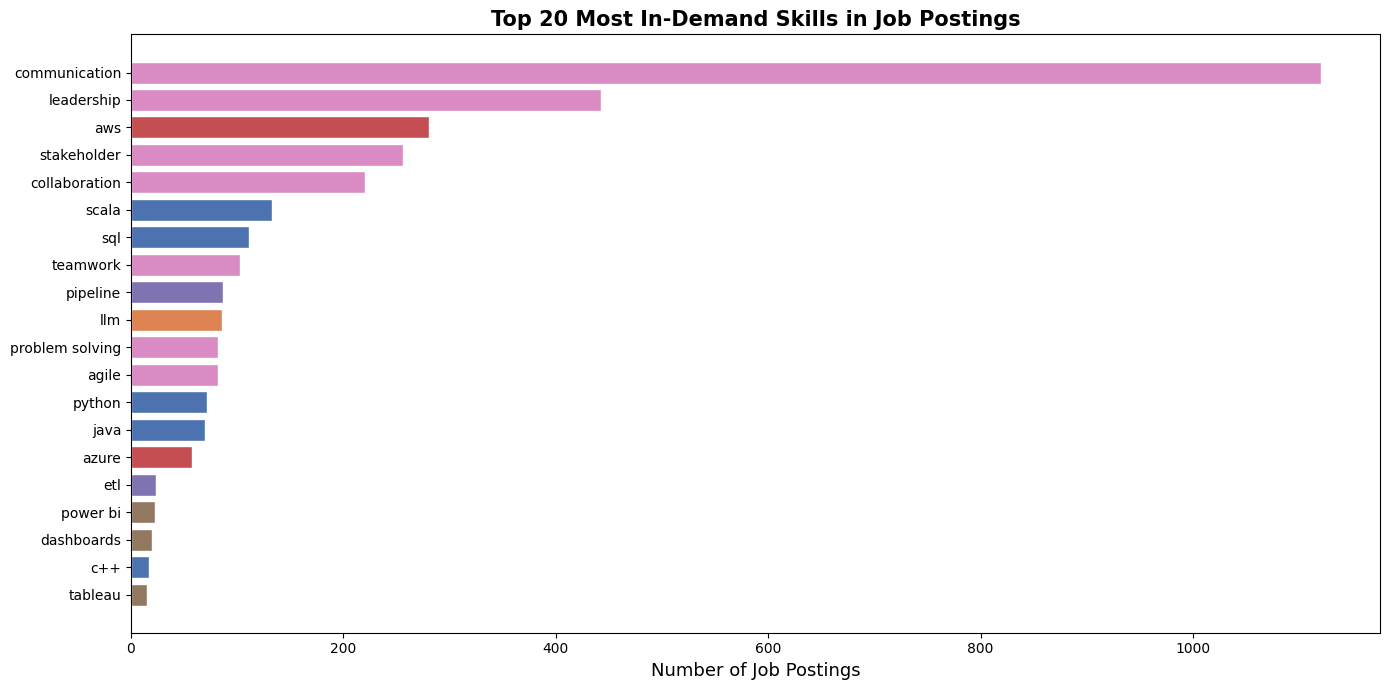

✅ Saved: top_skills.png


In [22]:
# STEP 5C: Visualize — Top 20 skills bar chart
import matplotlib.pyplot as plt
top_skills = skill_counter.most_common(20)
skills_names  = [s[0] for s in top_skills]
skills_counts = [s[1] for s in top_skills]
colors = [{'Programming':'#4C72B0','ML/AI':'#DD8452','Libraries':'#55A868',
           'Cloud':'#C44E52','Data Eng':'#8172B2','Visualization':'#937860',
           'Soft Skills':'#DA8BC3'}[ALL_SKILLS[s]] for s in skills_names]

plt.figure(figsize=(14, 7))
bars = plt.barh(skills_names[::-1], skills_counts[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Number of Job Postings', fontsize=13)
plt.title('Top 20 Most In-Demand Skills in Job Postings', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('top_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: top_skills.png")

/tmp/ipykernel_8638/679385956.py:26: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8638/679385956.py:27: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


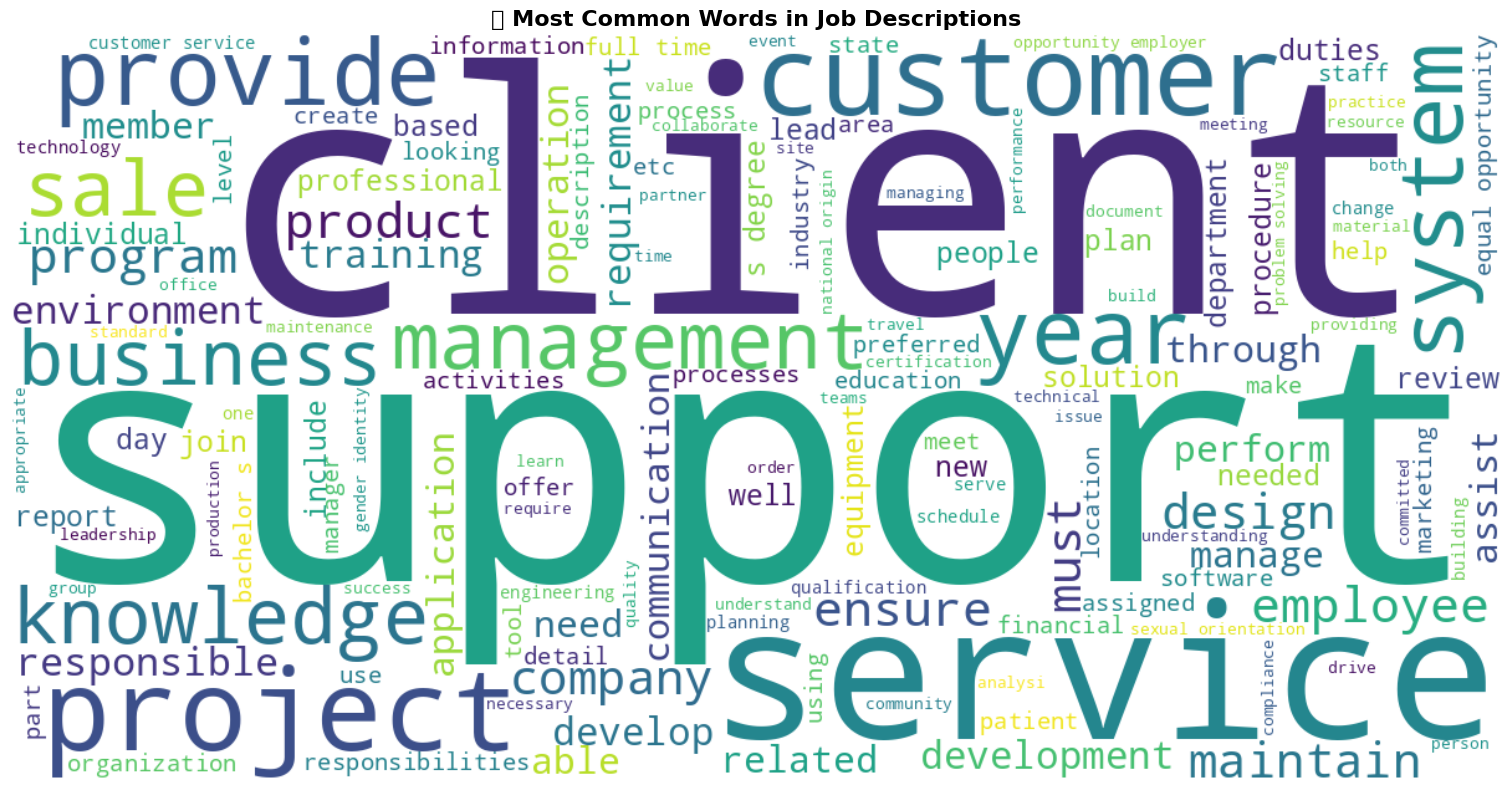

In [23]:
# STEP 5D: Word Cloud of job descriptions
import matplotlib.pyplot as plt
from wordcloud import WordCloud
all_text = ' '.join(df['description'].dropna().apply(clean_text).tolist())

# Remove very common English stopwords (from scratch!)
STOPWORDS = set(["the","and","to","of","a","in","is","for","with","on","that",
                 "are","as","this","be","will","an","or","we","our","you","have",
                 "from","at","by","your","not","all","can","their","it","its",
                 "we're","they","which","been","has","was","were","but","about",
                 "more","also","who","if","would","other","than","do","what",
                 "such","when","into","these","them","he","she","his","her",
                 "us","up","so","out","may","any","should","no","within","work",
                 "including","experience","job","role","team","skills","data",
                 "ability","strong","required","position","working","candidate"])

wc = WordCloud(width=1200, height=600, background_color='white',
               stopwords=STOPWORDS, max_words=150,
               colormap='viridis', prefer_horizontal=0.9)
wc.generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('💬 Most Common Words in Job Descriptions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

K-MEANS CLUSTERING FROM SCRATCH


In [24]:
# STEP 6A: Feature vector — represent each job as a skill presence vector
# This is "Bag of Words" but for skills!

TOP_SKILLS = [s for s, _ in skill_counter.most_common(30)]  # use top 30 skills

def job_to_vector(skills_found):
    """Convert a list of found skills into a binary feature vector."""
    return [1 if skill in skills_found else 0 for skill in TOP_SKILLS]

# Build the matrix (only postings that have at least 1 skill)
df_has_skills = df[df['skill_count'] > 0].copy().reset_index(drop=True)
vectors = [job_to_vector(s) for s in df_has_skills['skills_found']]

print(f"✅ Feature matrix: {len(vectors)} jobs × {len(TOP_SKILLS)} skill features")
print(f"   Skills tracked: {TOP_SKILLS}")

✅ Feature matrix: 1524 jobs × 30 skill features
   Skills tracked: ['communication', 'leadership', 'aws', 'stakeholder', 'collaboration', 'scala', 'sql', 'teamwork', 'pipeline', 'llm', 'problem solving', 'agile', 'python', 'java', 'azure', 'etl', 'power bi', 'dashboards', 'c++', 'tableau', 'gcp', 'spark', 'bash', 'kafka', 'machine learning', 'snowflake', 'data warehouse', 'dbt', 'databricks', 'nlp']


In [27]:
# STEP 6B: K-Means from scratch (exactly like Ch. 19 of the book!)
import random
import math

def euclidean_distance(v1, v2):
    """Straight-line distance between two vectors."""
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(v1, v2)))

def vector_mean(vectors):
    """Component-wise mean of a list of vectors."""
    n = len(vectors)
    return [sum(v[i] for v in vectors) / n for v in [vectors[0]] for i in range(len(v))]

def assign_clusters(vectors, centroids):
    """Assign each vector to the nearest centroid."""
    assignments = []
    for v in vectors:
        distances = [euclidean_distance(v, c) for c in centroids]
        assignments.append(distances.index(min(distances)))
    return assignments

def recompute_centroids(vectors, assignments, k):
    """Move each centroid to the mean of its assigned vectors."""
    centroids = []
    for cluster_id in range(k):
        cluster_vecs = [v for v, a in zip(vectors, assignments) if a == cluster_id]
        if cluster_vecs:
            centroids.append(vector_mean(cluster_vecs))
        else:
            centroids.append(random.choice(vectors))  # reinitialize empty cluster
    return centroids

def kmeans(vectors, k=5, max_iters=50, seed=42):
    """Full K-Means algorithm from scratch."""
    random.seed(seed)
    # Initialize: pick k random vectors as centroids
    centroids = random.sample(vectors, k)
    assignments = [-1] * len(vectors)

    for iteration in range(max_iters):
        new_assignments = assign_clusters(vectors, centroids)

        if new_assignments == assignments:
            print(f"  ✅ Converged at iteration {iteration}")
            break

        assignments = new_assignments
        centroids   = recompute_centroids(vectors, assignments, k)

        if iteration % 10 == 0:
            print(f"  Iteration {iteration}...")

    return assignments, centroids

# Run K-Means with k=5 clusters
print("🔄 Running K-Means clustering (from scratch)...")
K = 5
assignments, centroids = kmeans(vectors, k=K)
df_has_skills['cluster'] = assignments
print(f"\n✅ Done! Cluster distribution:")
print(Counter(assignments))

🔄 Running K-Means clustering (from scratch)...
  Iteration 0...
  Iteration 10...
  ✅ Converged at iteration 13

✅ Done! Cluster distribution:
Counter({3: 613, 0: 331, 1: 269, 4: 202, 2: 109})


In [28]:
# STEP 6C: Name each cluster by its top skills
print("\n🏷️ Cluster Profiles (Top Skills per Cluster):\n")
cluster_labels = {}
for cluster_id in range(K):
    cluster_df = df_has_skills[df_has_skills['cluster'] == cluster_id]
    cluster_skills = [s for skills in cluster_df['skills_found'] for s in skills]
    top = Counter(cluster_skills).most_common(5)
    label = " + ".join([s for s, _ in top[:2]])
    cluster_labels[cluster_id] = label
    top_titles = cluster_df['title'].value_counts().head(3).index.tolist()

    print(f"  Cluster {cluster_id} — '{label}'")
    print(f"    Size       : {len(cluster_df)} postings")
    print(f"    Top skills : {[s for s,_ in top]}")
    print(f"    Top titles : {top_titles}\n")


🏷️ Cluster Profiles (Top Skills per Cluster):

  Cluster 0 — 'leadership + communication'
    Size       : 331 postings
    Top skills : ['leadership', 'communication', 'aws', 'collaboration', 'llm']
    Top titles : ['National Team  Manager - Construction Materials Testing', 'National Team Manager - Special Inspection', 'Sales Account Executive']

  Cluster 1 — 'aws + sql'
    Size       : 269 postings
    Top skills : ['aws', 'sql', 'scala', 'python', 'stakeholder']
    Top titles : ['Sales Development Representative', 'Cashier Associate', 'PARTS MANAGER']

  Cluster 2 — 'aws + communication'
    Size       : 109 postings
    Top skills : ['aws', 'communication', 'stakeholder', 'collaboration', 'sql']
    Top titles : ['Staff Accountant', 'Field Office ISSM - Open Rank-RS-Albuquerque, NM', 'Human Resources Generalist']

  Cluster 3 — 'communication + collaboration'
    Size       : 613 postings
    Top skills : ['communication', 'collaboration', 'teamwork', 'scala', 'problem solving

FINAL VISUALIZATION

/tmp/ipykernel_8638/726344620.py:14: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8638/726344620.py:15: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('clusters_pie.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


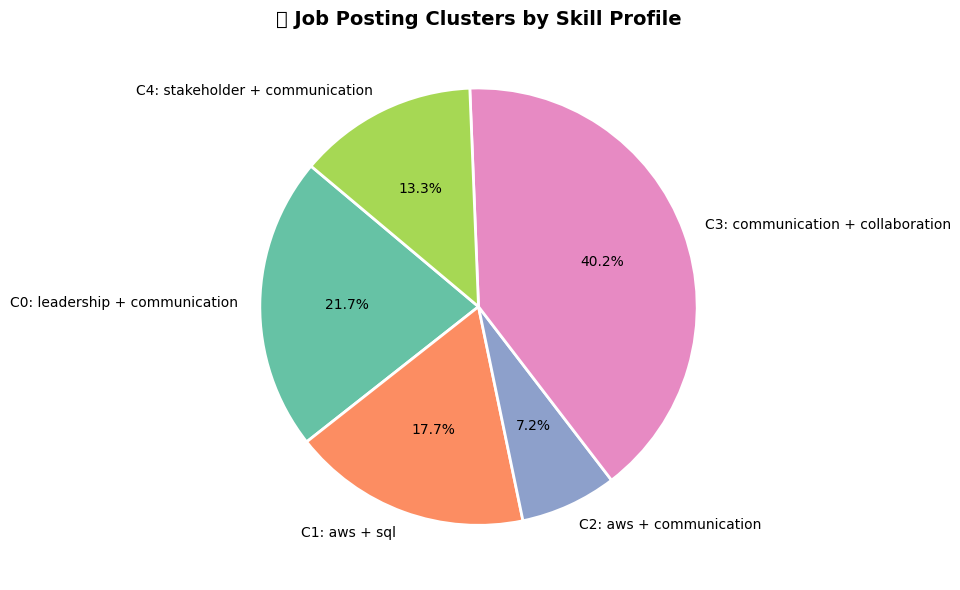

In [30]:
# STEP 7A: Cluster size pie chart
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
cluster_sizes = Counter(assignments)
labels = [f"C{k}: {cluster_labels[k]}" for k in range(K)]
sizes  = [cluster_sizes[k] for k in range(K)]

plt.figure(figsize=(10, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=sns.color_palette("Set2", K), startangle=140,
        wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('🎯 Job Posting Clusters by Skill Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clusters_pie.png', dpi=150, bbox_inches='tight')
plt.show()

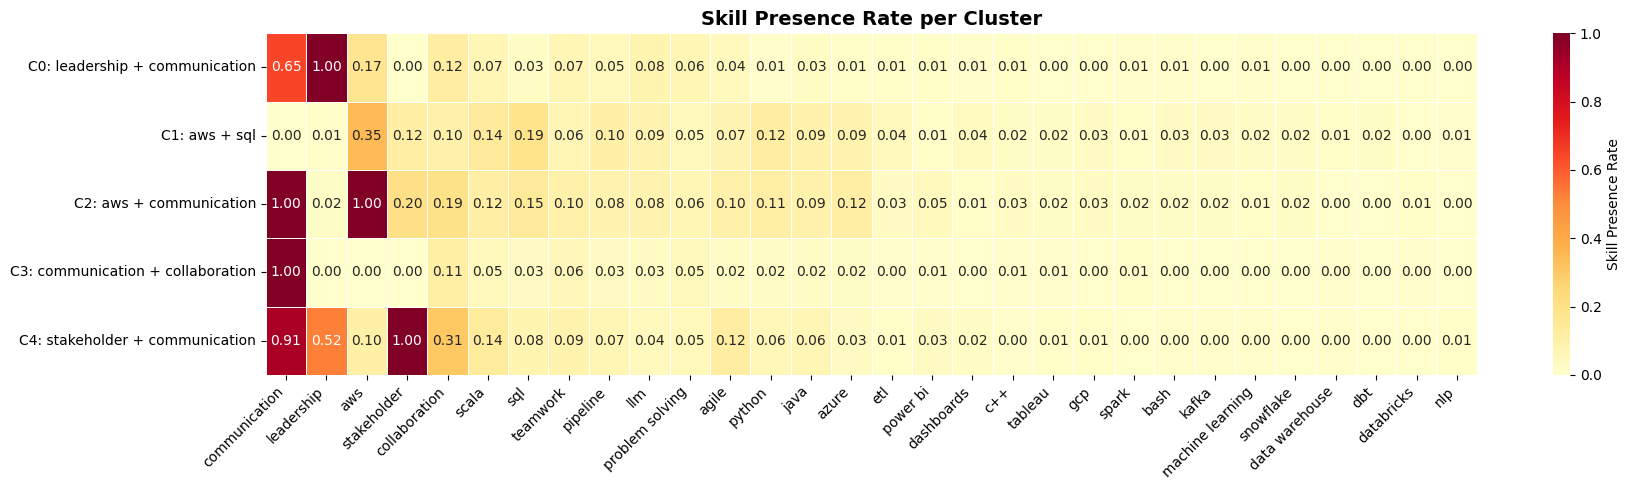

In [32]:
# STEP 7B: Skill heatmap across clusters
import matplotlib.pyplot as plt
import seaborn as sns
heatmap_data = []
for cluster_id in range(K):
    cluster_vecs = [v for v, a in zip(vectors, assignments) if a == cluster_id]
    if cluster_vecs:
        mean_vec = vector_mean(cluster_vecs)
    else:
        mean_vec = [0] * len(TOP_SKILLS)
    heatmap_data.append(mean_vec)

heatmap_df = pd.DataFrame(heatmap_data,
                           columns=TOP_SKILLS,
                           index=[f"C{i}: {cluster_labels[i]}" for i in range(K)])

plt.figure(figsize=(18, 5))
sns.heatmap(heatmap_df, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Skill Presence Rate'})
plt.title('Skill Presence Rate per Cluster', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('skill_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

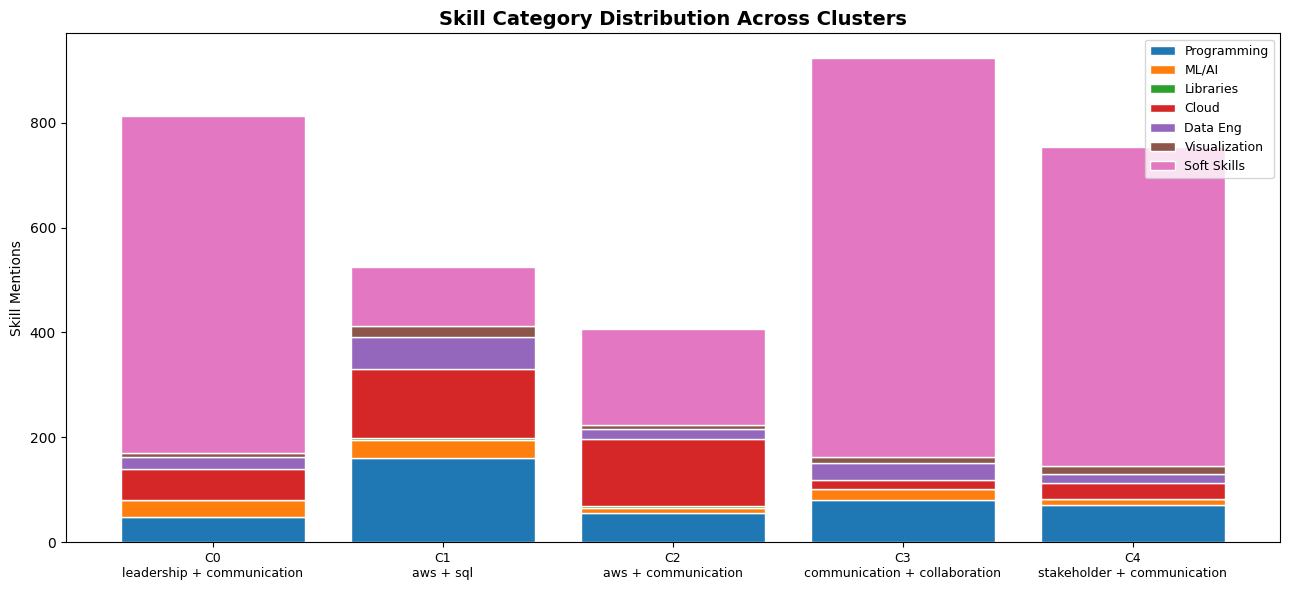

In [34]:
# STEP 7C: Category breakdown per cluster (stacked bar)
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
cat_cluster = defaultdict(lambda: defaultdict(int))
for _, row in df_has_skills.iterrows():
    for skill in row['skills_found']:
        cat_cluster[row['cluster']][ALL_SKILLS[skill]] += 1

categories = list(SKILLS.keys())
cluster_ids = list(range(K))
data = {cat: [cat_cluster[c][cat] for c in cluster_ids] for cat in categories}

x = range(K)
palette = sns.color_palette("tab10", len(categories))
bottom = [0] * K

plt.figure(figsize=(13, 6))
for i, cat in enumerate(categories):
    plt.bar(x, data[cat], bottom=bottom, label=cat, color=palette[i], edgecolor='white')
    bottom = [b + v for b, v in zip(bottom, data[cat])]

plt.xticks(range(K), [f"C{i}\n{cluster_labels[i]}" for i in range(K)], fontsize=9)
plt.ylabel('Skill Mentions')
plt.title('Skill Category Distribution Across Clusters', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('category_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

📐 Running Elbow Method to find optimal K...
  Iteration 0...
  ✅ Converged at iteration 5
  k=2, inertia=714.7
  Iteration 0...
  ✅ Converged at iteration 5
  k=3, inertia=632.4
  Iteration 0...
  ✅ Converged at iteration 9
  k=4, inertia=567.6
  Iteration 0...
  ✅ Converged at iteration 8
  k=5, inertia=554.6
  Iteration 0...
  ✅ Converged at iteration 8
  k=6, inertia=543.7
  Iteration 0...
  ✅ Converged at iteration 8
  k=7, inertia=495.0
  Iteration 0...
  ✅ Converged at iteration 6
  k=8, inertia=481.9
  Iteration 0...
  ✅ Converged at iteration 6
  k=9, inertia=465.0


/tmp/ipykernel_8638/3213444261.py:26: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8638/3213444261.py:27: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


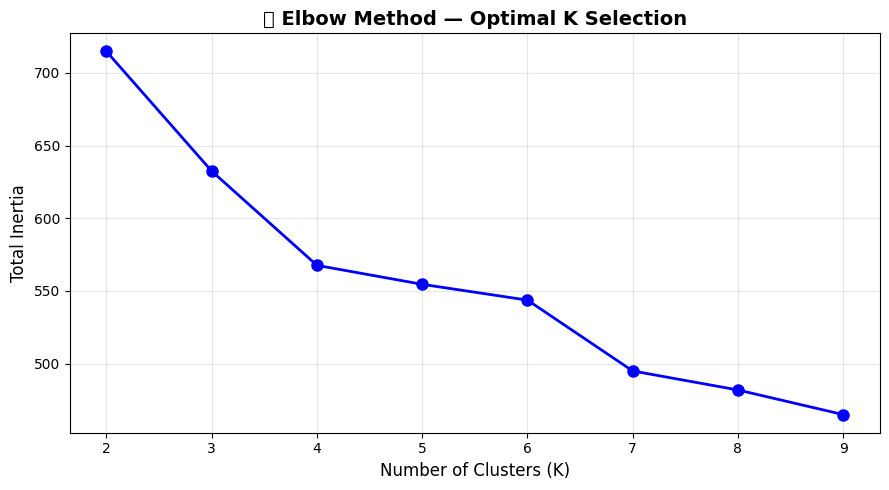

In [35]:
# STEP 7D: Elbow Method — find optimal K (Ch. 19 insight!)
import matplotlib.pyplot as plt
def total_inertia(vectors, assignments, centroids):
    """Total within-cluster variance (lower = tighter clusters)."""
    return sum(euclidean_distance(v, centroids[a]) ** 2
               for v, a in zip(vectors, assignments))

print("📐 Running Elbow Method to find optimal K...")
inertias = []
K_range = range(2, 10)

# Use a sample for speed
sample_vecs = random.sample(vectors, min(500, len(vectors)))

for k in K_range:
    a, c = kmeans(sample_vecs, k=k, max_iters=30)
    inertias.append(total_inertia(sample_vecs, a, c))
    print(f"  k={k}, inertia={inertias[-1]:.1f}")

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Total Inertia', fontsize=12)
plt.title('📐 Elbow Method — Optimal K Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()

FINAL- JOBROLE RECOMMENDOR

In [36]:
# STEP 8: Given YOUR skills, find the best matching cluster
from collections import defaultdict

def recommend_cluster(your_skills, centroids, cluster_labels):
    """
    Input : list of skills you know
    Output: best matching job cluster
    """
    your_vector = job_to_vector(your_skills)
    distances   = [euclidean_distance(your_vector, c) for c in centroids]
    best_cluster = distances.index(min(distances))

    print(f"\n🎯 Based on your skills: {your_skills}")
    print(f"\n   Best cluster match → Cluster {best_cluster}: '{cluster_labels[best_cluster]}'")
    print(f"\n   Distances to all clusters:")
    for i, d in enumerate(distances):
        marker = " ← YOU" if i == best_cluster else ""
        print(f"     Cluster {i} ({cluster_labels[i]:<30}): {d:.3f}{marker}")

    # Show matching jobs
    matches = df_has_skills[df_has_skills['cluster'] == best_cluster]
    print(f"\n📋 Sample job titles in your cluster:")
    for title in matches['title'].value_counts().head(8).index:
        print(f"     • {title}")

# ✏️ Edit this list with YOUR skills!
my_skills = ["python", "pandas", "machine learning", "sql", "tableau"]
recommend_cluster(my_skills, centroids, cluster_labels)


🎯 Based on your skills: ['python', 'pandas', 'machine learning', 'sql', 'tableau']

   Best cluster match → Cluster 1: 'aws + sql'

   Distances to all clusters:
     Cluster 0 (leadership + communication    ): 2.325
     Cluster 1 (aws + sql                     ): 1.890 ← YOU
     Cluster 2 (aws + communication           ): 2.372
     Cluster 3 (communication + collaboration ): 2.213
     Cluster 4 (stakeholder + communication   ): 2.442

📋 Sample job titles in your cluster:
     • Sales Development Representative
     • Cashier Associate
     • PARTS MANAGER
     • Senior Software Engineer
     • Field Service Technician
     • Project Manager
     • Retail Cashier
     • Full Stack Engineer
